In [138]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [139]:
path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/18.12/shell.jpeg'

In [140]:
img = tf.io.read_file(path)
img = tf.image.decode_jpeg(img, channels=3)

In [141]:
img = tf.image.convert_image_dtype(img, tf.float32)

In [142]:
shape = img.numpy().shape[:-1]
shape

(678, 1024)

In [143]:
long_dim = max(shape)
long_dim

1024

In [144]:
scale = 512/long_dim
scale

0.5

In [145]:
new_shape = tuple((np.array(shape)*scale).astype(np.int32))
new_shape

(np.int32(339), np.int32(512))

In [146]:
img = tf.image.resize(img, new_shape)

In [147]:
img = img[tf.newaxis,:]

In [148]:
img.numpy().shape

(1, 339, 512, 3)

In [149]:
original_image = tf.squeeze(img, axis = 0)

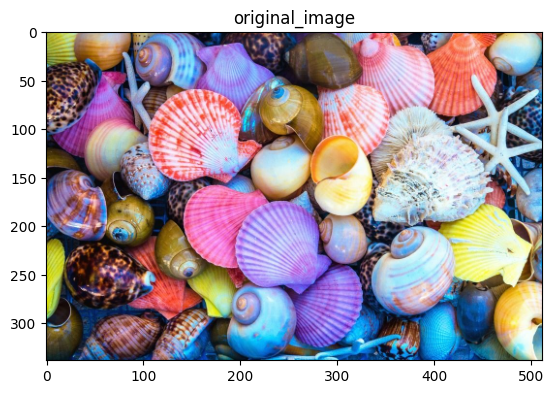

In [150]:
plt.title('original_image')
plt.imshow(original_image)

In [151]:
image = tf.Variable(np.random.rand(*img.shape).astype(np.float32))

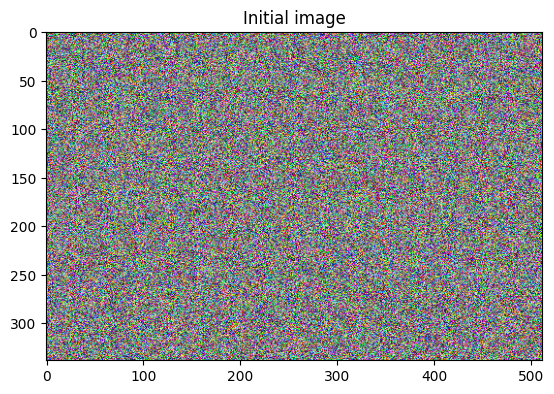

In [152]:
plt.title('Initial image')
plt.imshow(tf.squeeze(image, axis=0));

In [153]:
opt = tf.keras.optimizers.Adam(learning_rate = 0.5)

In [154]:
def loss (image):
  return tf.keras.losses.MeanSquaredError()(img, image)

In [155]:
def clip_0_1(image):
  return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

In [156]:
def train_step(image, loss_func):
  with tf.GradientTape() as tape:
    loss = loss_func(image)
  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))
  return loss.numpy()

In [157]:
for i in range (7):
  loss_value = train_step(image, loss)
  plt.title(f'Step {i}. Loss {loss_value:.3f}')
  plt.imshow(tf.squeeze(image, axis = 0))
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [158]:
path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/18.12/smolniy.jpeg'

In [159]:
img = tf.io.read_file(path)
img = tf.image.decode_image(img,channels=3)
img = tf.image.convert_image_dtype(img, tf.float32)

In [160]:
shape = img.numpy().shape[:-1]
long_dim = max(shape)
scale = 512/long_dim
new_shape = tuple((np.array(shape)*scale).astype(np.int32))
img = tf.image.resize(img,new_shape)
img = img[tf.newaxis,:]

In [161]:
img.numpy().shape

(1, 340, 512, 3)

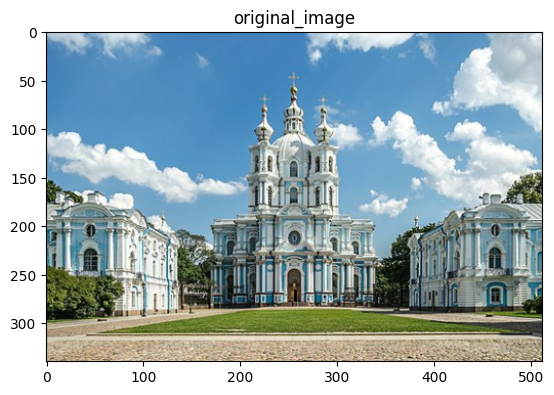

In [162]:
original_image = tf.squeeze(img, axis = 0)
plt.title ('original_image')
plt.imshow(original_image);

In [163]:
vgg = tf.keras.applications.VGG19(include_top=False, weights = 'imagenet')

In [164]:
for layer in vgg.layers:
  print(layer.name)

input_layer_17
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_conv4
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_conv4
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_conv4
block5_pool


In [165]:
outputs = [vgg.get_layer('block3_conv2').output]
model  = tf.keras.Model([vgg.input], outputs)
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,408 (4.37 MB)

 Trainable params: 1,145,408 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

In [166]:
def get_vgg_layers_model(layer_names):
  vgg = tf.keras.applications.VGG19(include_top = False, weights = 'imagenet')
  vgg.trainable = False
  outputs = [vgg.get_layer(name).output for name in layer_names]
  model = tf.keras.Model([vgg.input], outputs)
  return model

In [167]:
get_vgg_layers_model(['block3_conv1']).summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,328 (2.12 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 555,328 (2.12 MB)

In [168]:
class FeatureExtractor:
  def __init__ (self, layers):
    self.vgg_outputs_model = get_vgg_layers_model(layers)
    self.vgg_outputs_model.trainable = False
    self.content_layers = layers

  def __call__ (self, inputs):
    prepocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs*255)
    outputs = self.vgg_outputs_model(prepocessed_input)
    features_dict = {name: value for name, value in zip(self.content_layers,outputs)}

    return features_dict

In [169]:
content_layers = ['block2_conv2']
extractor = FeatureExtractor(content_layers)
results = extractor(img)

In [170]:
results.keys()

dict_keys(['block2_conv2'])

In [171]:
results['block2_conv2'].shape

TensorShape([170, 256, 128])

In [172]:
target_features = extractor(img)

In [173]:
def loss (image):
  current_features = extractor(image)
  loss = tf.add_n([tf.keras.losses.MeanSquaredError()(current_features[name], target_features[name]) for name in target_features.keys()])
  loss *= 1./len(target_features.keys())
  loss += tf.image.total_variation(image)*0.01
  return loss

In [174]:
def train_step(image, loss_func, optimizer):
  with tf.GradientTape() as tape:
    loss = loss_func(image)
  grad = tape.gradient(loss, image)
  optimizer.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))
  return loss.numpy()

In [175]:
features_layers = ['block4_conv1']
extractor = FeatureExtractor (features_layers)
target_features = extractor(img)

In [176]:
image = tf.Variable(np.random.rand(*img.shape).astype(np.float32))
opt = tf.keras.optimizers.Adam(learning_rate=0.2, beta_1=0.99, epsilon=0.1)

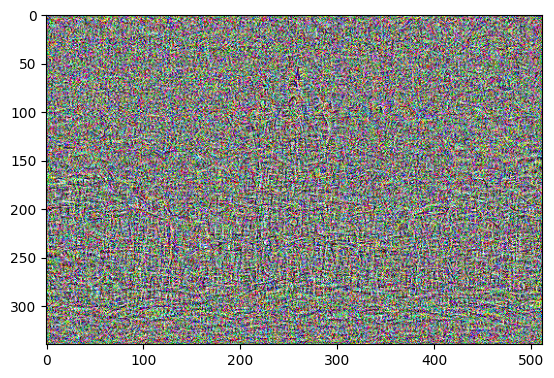

In [177]:
train_step(image, loss_func=loss, optimizer=opt)
generated_image = tf.squeeze(image, axis=0)
plt.imshow(generated_image)
plt.show()

In [178]:
epochs = 10
steps_per_epoch = 100
step = 0

for n in range (epochs):
  for m in range(steps_per_epoch):
    step+= 1
    train_step(image, loss_func=loss, optimizer=opt)
  generated_image = tf.squeeze(image, axis = 0)
  plt.title(f'Generated image, Optimize for {features_layers[0]}. Train step {step}')
  plt.imshow(tf.squeeze(image, axis = 0))
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [179]:
path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/18.12/shell.jpeg'

In [180]:
img = tf.io.read_file(path)
img = tf.image.decode_image(img,channels=3)
img = tf.image.convert_image_dtype(img, tf.float32)

In [181]:
shape = img.numpy().shape[:-1]
long_dim = max(shape)
scale = 512/long_dim
new_shape = tuple((np.array(shape)*scale).astype(np.int32))
img = tf.image.resize(img,new_shape)
img = img[tf.newaxis,:]

In [182]:
img.numpy().shape

(1, 339, 512, 3)

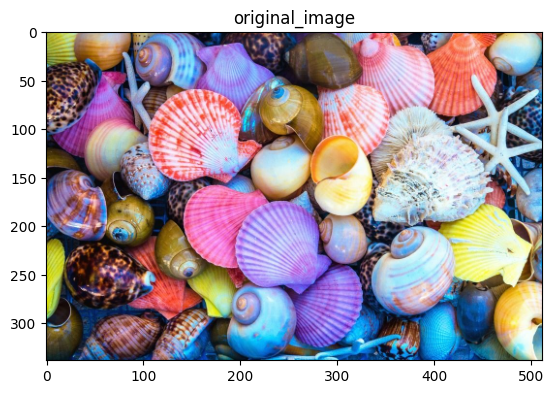

In [183]:
original_image = tf.squeeze(img, axis = 0)
plt.title ('original_image')
plt.imshow(original_image);

In [184]:
def gram_matrix(input_tensor):
  result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor,input_tensor)
  input_shape = tf.shape(input_tensor)

  num_locations = tf.cast(input_shape[1]*input_shape[2]*input_shape[3], tf.float32)
  return result/num_locations

In [185]:
class StyleExtractor:
  def __init__ (self, layers):
    self.vgg_outputs_model = get_vgg_layers_model(layers)
    self.vgg_outputs_model.trainable = False
    self.content_layers = layers

  def __call__ (self, inputs):
    prepocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs*255.)
    outputs = self.vgg_outputs_model(prepocessed_input)
    style_outputs = [gram_matrix(style_output) for style_output in outputs]
    features_dict = {name: value for name, value in zip(self.content_layers,outputs)}

    return features_dict

In [186]:
style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1',]

In [187]:
extractor = StyleExtractor(style_layers)
style_targets = extractor(img)

In [188]:
def loss (image):
  current_features = extractor(image)
  loss = tf.add_n([tf.keras.losses.MeanSquaredError()(current_features[name],style_targets[name]) for name in current_features.keys()])
  loss *= 1./len(current_features)
  loss += tf.image.total_variation(image)*0.0001
  return loss

In [189]:
def train_step(image, loss_func, optimizer):
  with tf.GradientTape() as tape:
    loss = loss_func(image)
  grad = tape.gradient(loss, image)
  optimizer.apply_gradients([(grad,image)])
  image.assign(clip_0_1(image))
  return loss.numpy()

In [193]:
feature_layers = ['block5_conv1']
extractor = FeatureExtractor(feature_layers)
target_features = extractor(img)

In [194]:
image = tf.Variable(np.random.rand(*img.shape).astype(np.float32))
opt = tf.keras.optimizers.Adam(learning_rate=0.2, beta_1=0.99, epsilon=0.1)

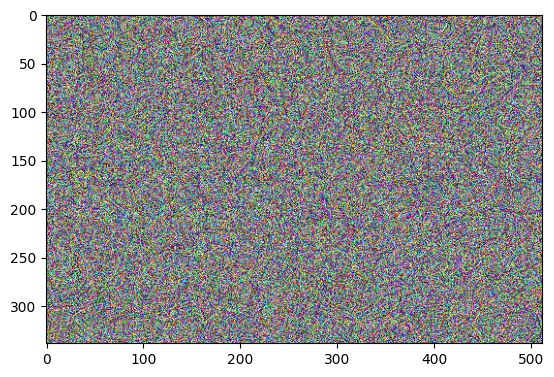

In [195]:
train_step(image, loss_func=loss,optimizer=opt)
generated_image = tf.squeeze(image,axis=0)
plt.imshow(generated_image)
plt.show()

In [196]:
epochs = 10
steps_per_epoch = 100

step = 0
for n in range (epochs):
  for m in range(steps_per_epoch):
    step+=1
    train_step(image, loss_func=loss, optimizer = opt)
  generated_image = tf.squeeze (image, axis = 0)
  plt.title(f'Generated image. Optimized for {feature_layers[0]}. Train step{step}')
  plt.imshow(generated_image)
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [197]:
epochs = 50
steps_per_epoch = 50

step = 0
for n in range (epochs):
  for m in range(steps_per_epoch):
    step+=1
    train_step(image, loss_func=loss, optimizer = opt)
  generated_image = tf.squeeze (image, axis = 0)
  plt.title(f'Generated image. Optimized for {feature_layers[0]}. Train step{step}')
  plt.imshow(generated_image)
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [198]:
path_style = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/18.12/picture.jpeg'
path_content = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/18.12/smolniy.jpeg'

In [199]:
img_style = tf.io.read_file(path_style)
img_style = tf.image.decode_image(img_style,channels=3)
img_style = tf.image.convert_image_dtype(img_style, tf.float32)

In [200]:
shape = img_style.numpy().shape[:-1]
long_dim = max(shape)
scale = 512/long_dim
new_shape = tuple((np.array(shape)*scale).astype(np.int32))
img_style = tf.image.resize(img_style,new_shape)
img_style = img_style[tf.newaxis,:]

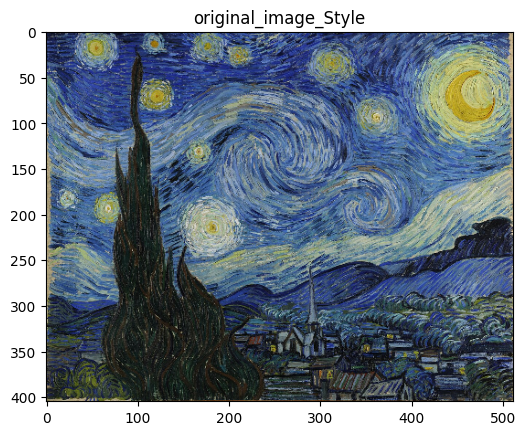

In [201]:
original_image_style = tf.squeeze(img_style, axis = 0)
plt.title ('original_image_Style')
plt.imshow(original_image_style);

In [202]:
img_content = tf.io.read_file(path_content)
img_content = tf.image.decode_image(img_content,channels=3)
img_content = tf.image.convert_image_dtype(img_content, tf.float32)

In [203]:
shape = img_content.numpy().shape[:-1]
long_dim = max(shape)
scale = 512/long_dim
new_shape = tuple((np.array(shape)*scale).astype(np.int32))
img_content = tf.image.resize(img_content,new_shape)
img_content = img_content[tf.newaxis,:]

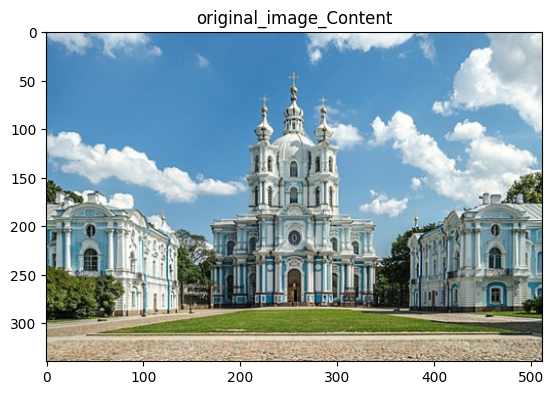

In [204]:
original_image_content = tf.squeeze(img_content, axis = 0)
plt.title ('original_image_Content')
plt.imshow(original_image_content);

In [206]:
class StyleAndContentExtractor:
  def __init__ (self, style_layers, content_layers):
    self.style_layers = style_layers
    self.content_layers = content_layers
    self.vgg_outputs_model = get_vgg_layers_model(style_layers + content_layers)
    self.num_style_layers = len (style_layers)
    self.vgg_outputs_model.trainable = False


  def __call__ (self, inputs):
    prepocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs*255.)
    outputs = self.vgg_outputs_model(prepocessed_input)
    features_dict = {}
    style_outputs, content_outputs = (outputs [: self.num_style_layers], outputs[self.num_style_layers:])
    style_outputs = [gram_matrix(style_output) for style_output in style_outputs]
    features_dict['style'] = {style_name: value for style_name, value in zip(self.style_layers,style_outputs)}
    features_dict['content'] = {content_name: value for content_name, value in zip(self.content_layers,content_outputs)}
    return features_dict

In [207]:
style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1',]

In [208]:
content_layers = ['block4_conv1']

In [209]:
extractor = StyleAndContentExtractor(style_layers=style_layers, content_layers=content_layers)

In [210]:
def style_content_loss(image, style_targets, content_targets):
  style_loss = None
  content_loss = None

  current_features = extractor(image)

  style_loss = tf.add_n([tf.keras.losses.MeanSquaredError()(current_features['style'][name],style_targets[name]) for name in current_features['style'].keys()])
  content_loss = tf.add_n([tf.keras.losses.MeanSquaredError()(current_features['content'][name],content_targets[name]) for name in current_features.keys()])
